<a href="https://colab.research.google.com/github/rishyg20/Alpha-Research---Assignment-2/blob/main/Alpha_Research_Assignment2_Pushkal_Rishabh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alpha Research — Assignment 2
### Team: Pushkal & Rishabh

In [49]:
!pip install fredapi
from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from datetime import datetime, timedelta
import time
import os
import requests

from google.colab import drive

drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/AlphaResearch_Assignment2/data/raw/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2: S&P 500 Constituents

In [50]:
start = time.time()
header = {'User-Agent': 'Chrome'}
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers= header)
tables = pd.read_html(response.text)
sp500 = tables[0]

today = datetime.today().strftime("%Y-%m-%d")
sp500['download_date'] = today
print(sp500.shape)
print(sp500.head())
display(sp500)
os.makedirs(DATA_PATH, exist_ok = True)
sp500.to_csv(DATA_PATH + f"sp500_constituents_{today}.csv", index = False)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

/tmp/ipykernel_22097/4023875586.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


(503, 9)
  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded download_date  
0    66740         1902    2026-05-19  
1    91142         1916    2026-05-19  
2     1800         1888    2026-05-19  
3  1551152  2013 (1888)    2026-05-19  
4  

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,download_date
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902,2026-05-19
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916,2026-05-19
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888,2026-05-19
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888),2026-05-19
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989,2026-05-19
...,...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011,2026-05-19
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997,2026-05-19
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969,2026-05-19
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927,2026-05-19


Time taken: 0.47 seconds


In [51]:
start = time.time()

stock_list = sp500['Symbol'].tolist()
end_date = datetime.today().strftime("%Y-%m-%d")
start_date = "2016-01-01"
#downloading Adj Stock price of SP500 constituents
prices = yf.download(stock_list, start = start_date, end = end_date, auto_adjust = True)
display(prices)
print(prices.shape)


end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")
#yfinance drops Adj Close when auto_adjust=True — adjusted prices are stored under Close instead.

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2016-01-01 -> 2026-05-19)')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


Price      Adj Close             Close                                      \
Ticker          BF.B BRK.B           A        AAPL        ABBV        ABNB   
Date                                                                         
2016-01-04       NaN   NaN   37.483681   23.709106   37.397274         NaN   
2016-01-05       NaN   NaN   37.354713   23.114969   37.241501         NaN   
2016-01-06       NaN   NaN   37.520542   22.662619   37.247974         NaN   
2016-01-07       NaN   NaN   35.926853   21.706154   37.137627         NaN   
2016-01-08       NaN   NaN   35.549171   21.820929   36.124947         NaN   
...              ...   ...         ...         ...         ...         ...   
2026-05-12       NaN   NaN  112.900002  294.799988  207.860001  135.479996   
2026-05-13       NaN   NaN  112.739998  298.869995  208.500000  132.970001   
2026-05-14       NaN   NaN  113.260002  298.209991  210.770004  133.669998   
2026-05-15       NaN   NaN  111.699997  300.230011  210.389999  132.850006   
2026-05-18       NaN   NaN  112.110001  297.839996  209.410004  134.300003   

Price                                                     ...   Volume  \
Ticker            ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                      ...            
2016-01-04  35.159653  21.823122   86.213058   91.970001  ...  3556800   
2016-01-05  35.151455  21.902363   86.661789   92.339996  ...  2722800   
2016-01-06  34.856609  21.937229   86.492439   91.019997  ...  4843200   
2016-01-07  34.021225  21.915041   83.952545   89.110001  ...  4917400   
2016-01-08  33.308704  21.686827   83.139778   87.849998  ...  5022600   
...               ...        ...         ...         ...  ...      ...   
2026-05-12  84.349998  94.309998  169.770004  240.830002  ...  6219200   
2026-05-13  83.830002  93.320000  159.639999  236.070007  ...  7638700   
2026-05-14  84.900002  93.459999  163.990005  237.009995  ...  4360100   
2026-05-15  84.470001  93.980003  168.820007  247.600006  ...  6414400   
2026-05-18  87.910004  95.870003  177.550003  255.639999  ...  4714800   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL      XYZ       YUM      ZBH   
Date                                                                          
2016-01-04  4249800  2819300  20400100  1353400  2751500   4821623  2104084   
2016-01-05  4286100  2141200  11993500  1075400  2352800   5273420  2294737   
2016-01-06  3316100  5191900  18826900  1866000  1850600   5049330  2751233   
2016-01-07  5525600  5212200  21263800  1555400  1636000  11005453  1829589   
2016-01-08  5740000  3005400  19033600  1471500   587300   5996184  1670969   
...             ...      ...       ...      ...      ...       ...      ...   
2026-05-12  1638900  9548100  16443100  1838600  6222300   1447100  2436500   
2026-05-13  1555100  3867900  15772800  1987300  6467700   1701000  2239200   
2026-05-14  2040700  4269500  11331500  1961000  5270800   1507100  2170800   
2026-05-15  1028100  4702200  27882400  2303900  5109300   2156600  2578900   
2026-05-18  1341000  4970200  20056100  2342400  4806000   1417700  2303200   

Price                          
Ticker         ZBRA       ZTS  
Date                           
2016-01-04   656200   2871700  
2016-01-05   611300   3116700  
2016-01-06   881900   4670500  
2016-01-07  1210600   4324400  
2016-01-08  1034700   4946100  
...             ...       ...  
2026-05-12  2879400  18430100  
2026-05-13  1392500  13085600  
2026-05-14  1264600   8714800  
2026-05-15  1224600   8952000  
2026-05-18  1067700   8843100  

[2608 rows x 2517 columns]

(2608, 2517)
Time taken: 104.64 seconds


In [52]:
start = time.time()
adj_close = prices['Close']
print(adj_close.shape)
print(adj_close.head())
adj_close.to_csv("DATA_PATH" + f"prices_close{today}.csv")
print(f"File saved for {adj_close.shape[1]} stocks, {adj_close.shape[0]} trading days")

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

(2608, 503)
Ticker              A       AAPL       ABBV  ABNB        ABT       ACGL  \
Date                                                                      
2016-01-04  37.483681  23.709106  37.397274   NaN  35.159653  21.823122   
2016-01-05  37.354713  23.114969  37.241501   NaN  35.151455  21.902363   
2016-01-06  37.520542  22.662619  37.247974   NaN  34.856609  21.937229   
2016-01-07  35.926853  21.706154  37.137627   NaN  34.021225  21.915041   
2016-01-08  35.549171  21.820929  36.124947   NaN  33.308704  21.686827   

Ticker            ACN       ADBE        ADI        ADM  ...         WY  \
Date                                                    ...              
2016-01-04  86.213058  91.970001  44.534794  26.397747  ...  20.020796   
2016-01-05  86.661789  92.339996  44.207569  26.692369  ...  20.067768   
2016-01-06  86.492439  91.019997  42.326050  26.044216  ...  19.624807   
2016-01-07  83.952545  89.110001  41.246216  25.425514  ...  18.899950   
2016-01-08  83.139

In [53]:
#converting stock prices to monthly returns
start = time.time()
monthly_prices = adj_close.resample('ME').last()
monthly_returns = monthly_prices.pct_change()
print(monthly_returns.head())
print(monthly_returns.shape)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

Ticker             A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2016-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-02-29 -0.007968 -0.001288 -0.005282   NaN  0.023514  0.005774 -0.050028   
2016-03-31  0.066934  0.127211  0.045962   NaN  0.079762  0.046512  0.151007   
2016-04-30  0.029823 -0.139921  0.078189   NaN -0.064364 -0.008579 -0.011990   
2016-05-31  0.121456  0.071773  0.031640   NaN  0.018766  0.030784  0.053578   

Ticker          ADBE       ADI       ADM  ...        WY      WYNN       XEL  \
Date                                      ...                                 
2016-01-31       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2016-02-29 -0.044654 -0.008057 -0.002009  ...  0.014448  0.232686  0.034536   
2016-03-31  0.101585  0.117003  0.038616  ...  0.206172  0.132760  0.066565   
2016-04-30  0.004478 -0.048488  0.099972  ..

/tmp/ipykernel_22097/490572405.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly_prices.pct_change()


In [54]:
#Feature creation - Momentum & Volatility

start = time.time()

momentum = monthly_returns.shift(1).rolling(window=11).sum()
print(momentum.shape)
print(momentum.head(15))
#Feature 2 : Volatility
volatility = monthly_returns.rolling(window = 12).std()
print(volatility.shape)

vix = yf.download("^VIX", start = start_date, end = end_date, auto_adjust = True)['Close']
vix_m = vix.resample("ME").last()
print(vix_m.shape)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

(125, 503)
Ticker             A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2016-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-02-29       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-03-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-04-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-05-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-06-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-07-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-08-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-09-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-10-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-11-30       NaN       Na

[*********************100%***********************]  1 of 1 completed

(125, 1)
Time taken: 0.45 seconds


In [55]:
#Macro data (FRED)



FRED_API_KEY = "4ebdf40a69f480d4b2d0969197ec30f6"
fred_api = Fred(api_key = FRED_API_KEY)

SERIES = {
    'DGS3MO'      : '3 Month Treasury Yield',
    'T10Y2Y'      : 'Yield Curve 10yr-2yr',
    'DTWEXBGS'    : 'Trade Weighted Dollar Index',
    'DCOILWTICO'  : 'WTI Crude Oil Price',
    'BAMLH0A0HYM2': 'Credit Spread',
    'UNRATE'      : 'Unemployment Rate',
    'CPIAUCSL'    : 'Inflation CPI',
    'GDPC1'       : 'Real GDP',
    'M2SL'        : 'M2 Money Supply',
    'PCECC96'     : 'Real Personal Consumption',
}

#Downloading each series and storing it in a dict
fred_dict = {}
for series_id, name in SERIES.items():
  fred_dict[series_id] = fred_api.get_series(series_id, observation_start = start_date, observation_end = end_date)
  print(f"Downloaded: {name}: {len(fred_dict[series_id])} observations")


fred_df = pd.DataFrame(fred_dict)

#Resampling to monthly

fred_monthly = fred_df.resample("ME").last().ffill()

#Saving to Drive
os.makedirs(DATA_PATH, exist_ok = True)
print(f"\nFRED data shape: {fred_monthly.shape}")
display(fred_monthly.head(10))
print(fred_monthly.isnull().sum())
fred_monthly= fred_monthly.drop(columns = ['BAMLH0A0HYM2']) #dropping credit spread data since 88 missing values
print(fred_monthly.isnull().sum())
print(f"\nFRED data shape: {fred_monthly.shape}")
fred_monthly.to_csv(DATA_PATH + f'fred_macro_{today}.csv')
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

Downloaded: 3 Month Treasury Yield: 2706 observations
Downloaded: Yield Curve 10yr-2yr: 2707 observations
Downloaded: Trade Weighted Dollar Index: 2706 observations
Downloaded: WTI Crude Oil Price: 2702 observations
Downloaded: Credit Spread: 792 observations
Downloaded: Unemployment Rate: 124 observations
Downloaded: Inflation CPI: 124 observations
Downloaded: Real GDP: 41 observations
Downloaded: M2 Money Supply: 123 observations
Downloaded: Real Personal Consumption: 41 observations

FRED data shape: (125, 10)


,DGS3MO,T10Y2Y,DTWEXBGS,DCOILWTICO,BAMLH0A0HYM2,UNRATE,CPIAUCSL,GDPC1,M2SL,PCECC96
2016-01-31,0.33,1.18,115.5731,33.66,NaN,4.8,237.652,19001.690,12518.5,12839.618
2016-02-29,0.33,0.96,114.2418,32.74,NaN,4.9,237.336,19001.690,12603.9,12839.618
2016-03-31,0.21,1.05,109.9191,36.94,NaN,5.0,238.080,19001.690,12661.8,12839.618
2016-04-30,0.22,1.06,108.8274,45.98,NaN,5.1,238.992,19062.709,12743.2,12903.306
2016-05-31,0.34,0.97,112.4276,49.10,NaN,4.8,239.557,19062.709,12802.0,12903.306
2016-06-30,0.26,0.91,112.1618,48.27,NaN,4.9,240.222,19062.709,12852.5,12903.306
2016-07-31,0.28,0.79,111.8740,41.54,NaN,4.8,240.101,19197.938,12911.9,12993.064
2016-08-31,0.33,0.78,112.4036,44.68,NaN,4.9,240.545,19197.938,12989.7,12993.064
2016-09-30,0.29,0.83,112.2795,47.72,NaN,5.0,241.176,19197.938,13054.9,12993.064
2016-10-31,0.34,0.98,114.0188,46.83,NaN,4.9,241.741,19304.352,13122.8,13060.061


DGS3MO           0
T10Y2Y           0
DTWEXBGS         0
DCOILWTICO       0
BAMLH0A0HYM2    88
UNRATE           0
CPIAUCSL         0
GDPC1            0
M2SL             0
PCECC96          0
dtype: int64
DGS3MO        0
T10Y2Y        0
DTWEXBGS      0
DCOILWTICO    0
UNRATE        0
CPIAUCSL      0
GDPC1         0
M2SL          0
PCECC96       0
dtype: int64

FRED data shape: (125, 9)
Time taken: 3.92 seconds


In [56]:
# DATA QUALITY OBSERVATIONS - FRED Macro Data
# =============================================

# DGS3MO (3M Treasury): 2706 daily obs → resampled to 125 monthly
# T10Y2Y (Yield Curve): 2707 daily obs → resampled to 125 monthly
# DTWEXBGS (Dollar Index): 2706 daily obs → resampled to 125 monthly
# DCOILWTICO (WTI Oil): 2702 daily obs → resampled to 125 monthly

# BAMLH0A0HYM2 (Credit Spread): 88 missing values at start of period
# → Series begins after 2016-01-01, shorter history than other series
# → Will handle with dropna() or ffill() during join

# UNRATE, CPIAUCSL, M2SL: Monthly frequency, 124 obs
# GDPC1, PCECC96: Quarterly frequency, only 41 obs
# → Forward filled to monthly using .ffill()

# OVERALL: 125 rows x 10 columns after resampling
# Matches monthly_returns shape (125 x 503) - ready for joining

In [57]:
#Section 4b - Fama French
import zipfile
import io

start = time.time()

#url from Kenneth French Data Library
ff_url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'

#download and unzip
r = requests.get(ff_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
ff_raw = pd.read_csv(z.open(z.namelist()[0]), skiprows = 3, index_col = 0)

print(ff_raw.head(10))
print(ff_raw.tail(10))
print(ff_raw.index[:5].tolist())

#Keeping monthly values only
def is_valid_month(val):
  try:
    v = int(str(val).strip())
    return 190000 <= v <= 210000
  except:
    return False

ff_monthly = ff_raw[ff_raw.index.map(is_valid_month)].copy()
print(ff_monthly.index[:10].tolist())  # show first 10 index values
print(type(ff_monthly.index[0]))       # show what type they are
ff_monthly.index = pd.to_datetime(ff_monthly.index.astype(str), format = "%Y%m")
ff_monthly.index = ff_monthly.index + pd.offsets.MonthEnd(0)

ff_monthly = ff_monthly.apply(pd.to_numeric, errors = 'coerce')/100

ff_monthly = ff_monthly[start_date:end_date]

ff_monthly.to_csv(DATA_PATH + f"fama_french_5factors_{today}.csv")

print(f"Fama - French shape: {ff_monthly.shape}")
print(f"Columns: {ff_monthly.columns.tolist()}")

display(ff_monthly.head())

end = time.time()



print(f"Time taken: {round(end - start,2)} seconds")



          Mkt-RF       SMB       HML       RMW       CMA        RF
196307     -0.39     -0.48     -0.81      0.64     -1.15      0.27
196308      5.08     -0.80      1.70      0.40     -0.38      0.25
196309     -1.57     -0.43      0.00     -0.78      0.15      0.27
196310      2.54     -1.34     -0.04      2.79     -2.25      0.29
196311     -0.86     -0.85      1.73     -0.43      2.27      0.27
196312      1.83     -1.89     -0.21      0.12     -0.25      0.29
196401      2.27      0.10      1.63      0.21      1.48      0.30
196402      1.55      0.33      2.81      0.11      0.81      0.26
196403      1.41      1.41      3.29     -2.03      2.98      0.31
196404      0.11     -1.48     -0.54     -1.32     -1.13      0.29
                                                      Mkt-RF       SMB  \
  2017                                                 21.51     -6.27   
  2018                                                 -6.83     -5.06   
  2019                                   

,Mkt-RF,SMB,HML,RMW,CMA,RF
2016-01-31,-0.0574,-0.0344,0.0208,0.0278,0.0305,0.0001
2016-02-29,-0.0007,0.0087,-0.0061,0.0331,0.0194,0.0002
2016-03-31,0.0695,0.0100,0.0122,0.0068,0.0001,0.0002
2016-04-30,0.0091,0.0123,0.0322,-0.0285,0.0177,0.0001
2016-05-31,0.0178,-0.0062,-0.0162,-0.0110,-0.0254,0.0001


Time taken: 0.24 seconds


In [61]:
# Joining the data

start = time.time()

# Stack each wide dataframe into long format
returns_long = monthly_returns.stack().reset_index()
returns_long.columns = ['date', 'ticker', 'return']

momentum_long = momentum.stack().reset_index()
momentum_long.columns = ['date', 'ticker', 'momentum']

volatility_long = volatility.stack().reset_index()
volatility_long.columns = ['date', 'ticker', 'volatility']

# Merge price-based signals
panel = returns_long.merge(momentum_long, on=['date', 'ticker'], how='inner')
panel = panel.merge(volatility_long, on=['date', 'ticker'], how='inner')
print(f"After price signals: {panel.shape}")

# Fix fred_monthly - always reset index cleanly
fred_clean = fred_monthly.copy()
if fred_clean.index.name == 'date' or fred_clean.index.name is not None:
    fred_clean = fred_clean.reset_index()
fred_clean.columns = [c if c != 'index' else 'date' for c in fred_clean.columns]
fred_clean = fred_clean[[c for c in fred_clean.columns if c not in ['level_0', 'level_1']]]

# Fix ff_monthly - same approach
ff_clean = ff_monthly.copy()
if ff_clean.index.name == 'date' or ff_clean.index.name is not None:
    ff_clean = ff_clean.reset_index()
ff_clean.columns = [c if c != 'index' else 'date' for c in ff_clean.columns]
ff_clean = ff_clean[[c for c in ff_clean.columns if c not in ['level_0', 'level_1']]]

print(fred_clean.columns.tolist())
print(ff_clean.columns.tolist())

print("fred_clean columns:", fred_clean.columns.tolist())
print("fred_clean index name:", fred_clean.index.name)
print("fred_clean head:")
print(fred_clean.head(2))

print("panel columns:", panel.columns.tolist())
print("panel index name:", panel.index.name)

fred_clean = fred_monthly.copy().reset_index()
fred_clean.columns = ['date'] + [c for c in fred_clean.columns[1:]]

ff_clean = ff_monthly.copy().reset_index()
ff_clean.columns = ['date'] + [c for c in ff_clean.columns[1:]]

print(fred_clean.columns.tolist())
print(fred_clean.head(2))

# Merge macro data
panel = panel.merge(fred_clean, on='date', how='left')
panel = panel.merge(ff_clean, on='date', how='left')

print(f"Final panel: {panel.shape}")
display(panel.head())

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

After price signals: (54879, 5)
['DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
fred_clean columns: ['DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
fred_clean index name: None
fred_clean head:
            DGS3MO  T10Y2Y  DTWEXBGS  DCOILWTICO  UNRATE  CPIAUCSL     GDPC1  \
2016-01-31    0.33    1.18  115.5731       33.66     4.8   237.652  19001.69   
2016-02-29    0.33    0.96  114.2418       32.74     4.9   237.336  19001.69   

               M2SL    PCECC96  
2016-01-31  12518.5  12839.618  
2016-02-29  12603.9  12839.618  
panel columns: ['date', 'ticker', 'return', 'momentum', 'volatility']
panel index name: None
['date', 'DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
        date  DGS3MO  T10Y2Y  DTWEXBGS  DCOILWTICO  UNRATE  CPIAUCSL  \
0 2016-01-31    0.33    1.18  115.5731       33.66    

,date,ticker,return,momentum,volatility,DGS3MO,T10Y2Y,DTWEXBGS,DCOILWTICO,UNRATE,CPIAUCSL,GDPC1,M2SL,PCECC96,Mkt-RF,SMB,HML,RMW,CMA,RF
0,2017-01-31,A,0.074846,0.218915,0.055968,0.52,1.26,116.2241,52.75,4.7,243.618,19398.343,13315.7,13160.475,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004
1,2017-01-31,AAPL,0.047746,0.225023,0.070427,0.52,1.26,116.2241,52.75,4.7,243.618,19398.343,13315.7,13160.475,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004
2,2017-01-31,ABBV,-0.014267,0.177740,0.056882,0.52,1.26,116.2241,52.75,4.7,243.618,19398.343,13315.7,13160.475,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004
3,2017-01-31,ABT,0.094502,0.053314,0.066635,0.52,1.26,116.2241,52.75,4.7,243.618,19398.343,13315.7,13160.475,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004
4,2017-01-31,ACGL,0.023873,0.255619,0.039078,0.52,1.26,116.2241,52.75,4.7,243.618,19398.343,13315.7,13160.475,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004


Time taken: 0.11 seconds


In [62]:
start = time.time()

print(panel.dtypes)
print(panel.isnull().sum())
panel = panel.dropna(subset = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF'])
print(panel.dtypes)
print(panel.isnull().sum())
print(panel.shape)

#Adding derived macro factors
panel['CPI_change'] = panel.groupby('ticker')['CPIAUCSL'].pct_change()
panel['GDP_growth'] = panel.groupby('ticker')['GDPC1'].pct_change()
panel['Oil_change'] = panel.groupby('ticker')['DCOILWTICO'].pct_change()

panel = panel.dropna(subset = ['CPI_change', 'GDP_growth', 'Oil_change'])
print(panel.isnull().sum())
print(panel.shape)

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")




date          datetime64[ns]
ticker                object
return               float64
momentum             float64
volatility           float64
DGS3MO               float64
T10Y2Y               float64
DTWEXBGS             float64
DCOILWTICO           float64
UNRATE               float64
CPIAUCSL             float64
GDPC1                float64
M2SL                 float64
PCECC96              float64
Mkt-RF               float64
SMB                  float64
HML                  float64
RMW                  float64
CMA                  float64
RF                   float64
dtype: object
date             0
ticker           0
return           0
momentum         0
volatility       0
DGS3MO           0
T10Y2Y           0
DTWEXBGS         0
DCOILWTICO       0
UNRATE           0
CPIAUCSL         0
GDPC1            0
M2SL             0
PCECC96          0
Mkt-RF        1000
SMB           1000
HML           1000
RMW           1000
CMA           1000
RF            1000
dtype: int64
date         

In [66]:
#Forward return - predictand

if 'forward_return' not in panel.columns:
    panel['forward_return'] = panel.groupby('ticker')['return'].shift(-1)
    panel = panel.dropna(subset=['forward_return'])
print(panel.shape)


# Define X and Y
y = panel['forward_return']

X_cols = [
    'momentum',
    'volatility',
    'DGS3MO',
    'T10Y2Y',
    'Mkt-RF',
    'SMB',
    'HML',
    'RMW',
    'CMA',
    'CPI_change',
    'GDP_growth',
    'Oil_change'
]

X = panel[X_cols]

X = sm.add_constant(X)

print(X.shape)
print(y.shape)

model = sm.OLS(y, X)

results = model.fit()

print(results.summary())

(52879, 24)
(52879, 13)
(52879,)
                            OLS Regression Results                            
Dep. Variable:         forward_return   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        18:06:38   Log-Likelihood:                 51784.
No. Observations:               52879   AIC:                        -1.035e+05
Df Residuals:                   52866   BIC:                        -1.034e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.01

R-squared: 0.0389
Adjusted R-squared: 0.0387
F-statistic p-value: 0.000000
Number of observations: 52879


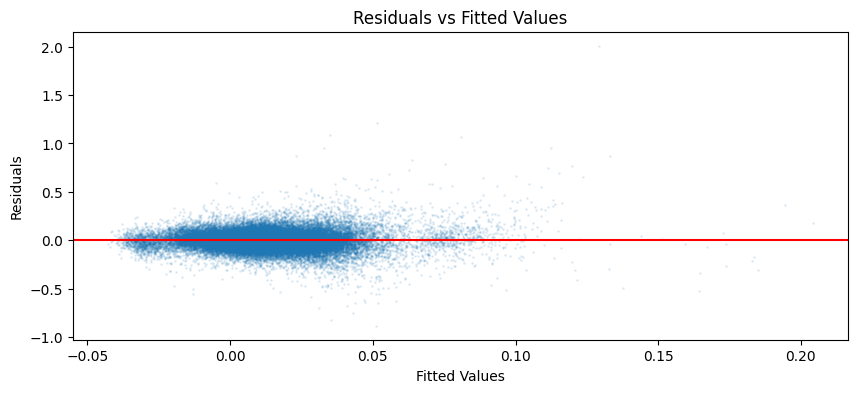

In [67]:
# Key results summary
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"F-statistic p-value: {results.f_pvalue:.6f}")
print(f"Number of observations: {results.nobs:.0f}")

# Plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(results.fittedvalues, results.resid, alpha=0.1, s=1)
plt.axhline(0, color='red')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.savefig(DATA_PATH + 'residuals_plot.png')
plt.show()